# Stage 2 - Cleaning and Preprocessing

Stage 1 looked at the raw data. Now we fix the one real data-quality issue,
split the data **before** fitting anything, and build the single preprocessing
pipeline that every later stage will reuse (model training, similarity search,
and the dashboard).

All logic lives in `src/`; this notebook calls it and explains the results.

In [1]:
import sys
from pathlib import Path

here = Path.cwd()
project_root = here if (here / "src").exists() else here.parent
sys.path.insert(0, str(project_root))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import (
    DATA_PROCESSED_DIR, MODELS_DIR, FIGURES_DIR,
    NUMERIC_COLUMNS, TARGET_COLUMN,
)
from src.data.load import load_raw_data
from src.data.clean import clean_data
from src.data.split import split_data, FEATURE_COLUMNS
from src.features.preprocessor import (
    build_preprocessor, transform_to_frame, save_preprocessor, load_preprocessor,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1. Fix the TotalCharges column

In [2]:
raw = load_raw_data()

print("Before cleaning")
print("  dtype:", raw["TotalCharges"].dtype)
print("  blank values:", (raw["TotalCharges"].str.strip() == "").sum())

Before cleaning
  dtype: object
  blank values: 11


In [3]:
df = clean_data(raw)

print("After cleaning")
print("  dtype:", df["TotalCharges"].dtype)
print("  missing values:", df["TotalCharges"].isnull().sum())

# The rows that were blank belong to brand-new customers (tenure 0).
print()
print("Former blank rows, now filled with 0:")
print(df.loc[raw["TotalCharges"].str.strip() == "", ["tenure", "MonthlyCharges", "TotalCharges"]].head())

After cleaning
  dtype: float64
  missing values: 0

Former blank rows, now filled with 0:
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           0.0
753        0           20.25           0.0
936        0           80.85           0.0
1082       0           25.75           0.0
1340       0           56.05           0.0


**Conclusion:** `TotalCharges` is now numeric with no missing values. The 11
blank rows were all `tenure = 0` customers, so a total of 0 is the correct value:
they have not been billed a full cycle yet. No rows were dropped. Everything else
in the raw data was already clean (Stage 1 found no duplicates or impossible
values), so this is the only cleaning step needed.

## 2. Split before fitting anything

In [4]:
split = split_data(df)

for name, X, y in [
    ("train", split.X_train, split.y_train),
    ("val", split.X_val, split.y_val),
    ("test", split.X_test, split.y_test),
]:
    print(f"{name:5s}: {len(X):5d} rows | churn rate {y.mean():.3f}")

train:  4225 rows | churn rate 0.265
val  :  1409 rows | churn rate 0.265
test :  1409 rows | churn rate 0.265


**Conclusion:** The data is split 60/20/20 into train (4,225), validation
(1,409), and test (1,409). The churn rate is **0.265 in every split** because the
split is stratified, so each set is representative. From here on, preprocessing is
fit **only on the training set**; validation and test are transformed with those
fitted values. This is what prevents data leakage.

## 3. The preprocessing pipeline

The preprocessor is one `ColumnTransformer` with two branches:

- **Numeric** (`tenure`, `MonthlyCharges`, `TotalCharges`): median imputation,
  then scaling.
- **Categorical** (the 16 service/account/demographic columns): most-frequent
  imputation, then one-hot encoding with `handle_unknown="ignore"` so a new
  category typed in the dashboard does not crash the pipeline.

In [5]:
build_preprocessor("standard")

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 ['tenure', 'MonthlyCharges', 'TotalCharges']),
                                ('categorical',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encode',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['gender', 'SeniorCitizen', 'Partner',
                                  'Dependents', 'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod'])])

## 4. Compare StandardScaler and RobustScaler

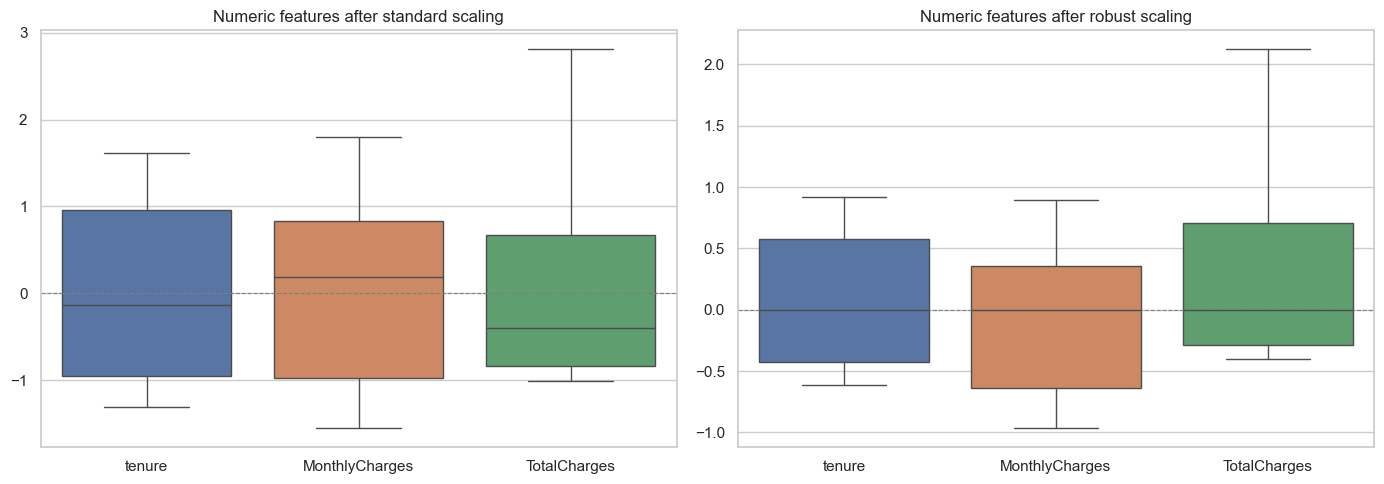

In [6]:
# Fit each scaler choice on the TRAINING data only, then look at the numeric
# columns after scaling. We compare distributions, not validation scores, because
# scaling mainly changes the shape/range of the numeric features.
comparison = {}
for choice in ["standard", "robust"]:
    preprocessor = build_preprocessor(choice)
    preprocessor.fit(split.X_train)
    processed = transform_to_frame(preprocessor, split.X_train)
    numeric_columns = [c for c in processed.columns if c.startswith("numeric__")]
    comparison[choice] = processed[numeric_columns]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax, (choice, frame) in zip(axes, comparison.items()):
    labels = [c.replace("numeric__", "") for c in frame.columns]
    sns.boxplot(data=frame.rename(columns=dict(zip(frame.columns, labels))), ax=ax)
    ax.set_title(f"Numeric features after {choice} scaling")
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "scaling_comparison.png", dpi=120, bbox_inches="tight")

**Decision log - scaler choice**

- **What was tested:** StandardScaler (mean 0, std 1) vs RobustScaler (median/IQR)
  on the training numeric features.
- **Why:** Stage 1 found no extreme or impossible outliers, but the reference
  notebook used RobustScaler, so it is worth checking rather than assuming.
- **Result:** Both give similar, well-behaved ranges. RobustScaler centres on the
  median and is slightly tighter against tails, but there are no harmful outliers
  for it to protect against here.
- **Decision:** Use **StandardScaler**. It centres and unit-scales every feature,
  which is the natural fit for the cosine-similarity vectors in Stage 5 and for
  logistic regression in Stage 3. RobustScaler stays available via
  `build_preprocessor("robust")` if a later stage shows a reason to switch.

## 5. Fit the chosen preprocessor and inspect the output

In [7]:
preprocessor = build_preprocessor("standard")
preprocessor.fit(split.X_train)

X_train_processed = transform_to_frame(preprocessor, split.X_train)
print("Processed training shape:", X_train_processed.shape)
print("Number of features after encoding:", X_train_processed.shape[1])
print()
print("Feature names:")
for name in preprocessor.get_feature_names_out():
    print(" ", name)

Processed training shape: (4225, 46)
Number of features after encoding: 46

Feature names:
  numeric__tenure
  numeric__MonthlyCharges
  numeric__TotalCharges
  categorical__gender_Female
  categorical__gender_Male
  categorical__SeniorCitizen_0
  categorical__SeniorCitizen_1
  categorical__Partner_No
  categorical__Partner_Yes
  categorical__Dependents_No
  categorical__Dependents_Yes
  categorical__PhoneService_No
  categorical__PhoneService_Yes
  categorical__MultipleLines_No
  categorical__MultipleLines_No phone service
  categorical__MultipleLines_Yes
  categorical__InternetService_DSL
  categorical__InternetService_Fiber optic
  categorical__InternetService_No
  categorical__OnlineSecurity_No
  categorical__OnlineSecurity_No internet service
  categorical__OnlineSecurity_Yes
  categorical__OnlineBackup_No
  categorical__OnlineBackup_No internet service
  categorical__OnlineBackup_Yes
  categorical__DeviceProtection_No
  categorical__DeviceProtection_No internet service
  categori

In [8]:
X_train_processed.head()

,numeric__tenure,numeric__MonthlyCharges,numeric__TotalCharges,categorical__gender_Female,categorical__gender_Male,categorical__SeniorCitizen_0,categorical__SeniorCitizen_1,categorical__Partner_No,categorical__Partner_Yes,categorical__Dependents_No,categorical__Dependents_Yes,categorical__PhoneService_No,categorical__PhoneService_Yes,categorical__MultipleLines_No,categorical__MultipleLines_No phone service,categorical__MultipleLines_Yes,categorical__InternetService_DSL,categorical__InternetService_Fiber optic,categorical__InternetService_No,categorical__OnlineSecurity_No,categorical__OnlineSecurity_No internet service,categorical__OnlineSecurity_Yes,categorical__OnlineBackup_No,categorical__OnlineBackup_No internet service,categorical__OnlineBackup_Yes,categorical__DeviceProtection_No,categorical__DeviceProtection_No internet service,categorical__DeviceProtection_Yes,categorical__TechSupport_No,categorical__TechSupport_No internet service,categorical__TechSupport_Yes,categorical__StreamingTV_No,categorical__StreamingTV_No internet service,categorical__StreamingTV_Yes,categorical__StreamingMovies_No,categorical__StreamingMovies_No internet service,categorical__StreamingMovies_Yes,categorical__Contract_Month-to-month,categorical__Contract_One year,categorical__Contract_Two year,categorical__PaperlessBilling_No,categorical__PaperlessBilling_Yes,categorical__PaymentMethod_Bank transfer (automatic),categorical__PaymentMethod_Credit card (automatic),categorical__PaymentMethod_Electronic check,categorical__PaymentMethod_Mailed check
2312,-0.579543,-1.489929,-0.825501,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
5227,-1.025518,1.047953,-0.721184,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
6404,0.798927,1.484829,1.511956,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
88,0.555668,-1.494931,-0.595135,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
6496,0.312408,1.236377,0.790441,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


**Conclusion:** The 19 input features expand to **46 numeric features**: 3
scaled numeric columns plus the one-hot columns for the 16 categorical fields.
Every column keeps a readable name (for example `categorical__Contract_Two year`),
so later stages and explanations never have to guess what a column means.

## 6. Multicollinearity check on the processed numeric features

In [9]:
numeric_processed = X_train_processed[[c for c in X_train_processed.columns if c.startswith("numeric__")]]
correlation = numeric_processed.corr()
print(correlation.round(2))

                         numeric__tenure  numeric__MonthlyCharges  \
numeric__tenure                     1.00                     0.26   
numeric__MonthlyCharges             0.26                     1.00   
numeric__TotalCharges               0.83                     0.65   

                         numeric__TotalCharges  
numeric__tenure                           0.83  
numeric__MonthlyCharges                   0.65  
numeric__TotalCharges                     1.00  


**Conclusion:** `tenure` and `TotalCharges` are strongly correlated (**0.83**),
which makes sense because the running total grows with how long a customer stays.
This is expected redundancy, not leakage.

**Decision:** Keep both columns for now. Tree models (Random Forest, XGBoost) are
unaffected by correlated inputs, and logistic regression will use regularization.
We would rather let Stage 3's validation results decide whether dropping
`TotalCharges` helps than remove a possibly useful feature up front. This matches
the project rule to test removal instead of assuming it.

## 7. Save the artifacts for later stages

In [10]:
preprocessor_path = MODELS_DIR / "preprocessor.joblib"
clean_data_path = DATA_PROCESSED_DIR / "telco_clean.csv"

save_preprocessor(preprocessor, preprocessor_path)
df.to_csv(clean_data_path, index=False)

print("Saved preprocessor to:", preprocessor_path)
print("Saved cleaned data to:", clean_data_path)

Saved preprocessor to: Q:\Customer Churn\customer-churn-retention\models\preprocessor.joblib
Saved cleaned data to: Q:\Customer Churn\customer-churn-retention\data\processed\telco_clean.csv


In [11]:
# Confirm the saved preprocessor loads in a fresh object and transforms identically.
reloaded = load_preprocessor(preprocessor_path)
original_output = transform_to_frame(preprocessor, split.X_val)
reloaded_output = transform_to_frame(reloaded, split.X_val)

identical = original_output.equals(reloaded_output)
print("Reloaded preprocessor produces identical output:", identical)

Reloaded preprocessor produces identical output: True


**Conclusion:** The fitted preprocessor and the cleaned dataset are saved.
The reload check confirms the saved object transforms data exactly like the one in
memory, so Stage 3 and the dashboard can rely on it. We save the **cleaned data**
and re-create the splits with the fixed seed in later stages, which keeps the
train/validation/test sets identical everywhere without storing several copies.

## Summary of Stage 2

1. Converted `TotalCharges` to numeric and set the 11 new-customer blanks to 0 -
   the only cleaning the dataset needed.
2. Split the data 60/20/20, stratified, **before** fitting any transformation, so
   preprocessing only ever learns from the training set.
3. Built one `ColumnTransformer` (impute -> scale numeric, impute -> one-hot
   categorical) that turns a customer into 46 named numeric features and ignores
   unknown categories.
4. Compared StandardScaler vs RobustScaler and chose StandardScaler, with reasons
   recorded.
5. Flagged the tenure/TotalCharges correlation (0.83) and chose to keep both,
   leaving the removal question for Stage 3 validation.
6. Saved the fitted preprocessor and cleaned data, and verified the saved
   preprocessor reloads and transforms identically.

**Next (Stage 3):** load the cleaned data, re-create the same splits, and compare
models (dummy, logistic regression, random forest, XGBoost) with proper metrics
and leakage-safe SMOTE inside an imblearn pipeline.